### Introduction to Manifold Diffusion Geometry

This notebook follows the computation in [Manifold Diffusion Geometry: Curvature, Tangent Spaces, and Dimension](https://arxiv.org/abs/2411.04100). The aim is to take a point cloud and compute familiar manifold geometry: tangent spaces, dimension, and scalar curvature.

We assume the data behave like points sampled from a low-dimensional manifold embedded in Euclidean space. We use diffusion geometry to estimate the intrinsic geometry from the heat flow on the data. The heat flow gives a Laplacian, and the Laplacian gives the carré du champ

$$
\Gamma(f,h)=g(\nabla f,\nabla h).
$$

Once $\Gamma$ is known, Riemannian geometry becomes linear algebra.

*The plots in this notebook are interactive*


In [1]:
from pathlib import Path
import site
import sys

import os

import numpy as np

from preprocess_file import compute_contrast_norm, sample_from_data_set
import numpy as np
from opt_einsum import contract
from TDA.optical_flow_torus.preprocess_file import preprocess_file, get_high_contrast_patches, normalize_patches, knn_density_threshold
import plotly.io as pio

# # Keep imports on this repo/conda env when running the notebook directly.
# sys.path = [path for path in sys.path if not path.startswith(site.getusersitepackages())]
# if Path.cwd().name == "intro_notebooks":
#     sys.path.insert(0, "..")

# from diffusion_geometry import DiffusionGeometry
# from diffusion_geometry.visualisation import plot_scatter_3d, plot_2form_3d

# pio.renderers.default = "notebook_connected"


In [12]:
folderpath = "/home/martincc/Downloads/MPI-Sintel-complete/training/flow/"

NUM_PATCHES = 385
PATCH_SIZE = 3
K = 300
PERCENT = 20
subfolders = sorted(
    entry.path for entry in os.scandir(folderpath) if entry.is_dir()
)

allpatches_list = []
for tempdir in subfolders:
    # Get all .flo files in this subdirectory and process them.
    filelist = sorted(
        f for f in os.listdir(tempdir) if f.endswith(".flo")
    )
    numfiles = len(filelist)
    folderpatches = np.zeros((NUM_PATCHES * numfiles, 2 * PATCH_SIZE ** 2 + 1))
    for i, fname in enumerate(filelist):
        filepath = os.path.join(tempdir, fname)

        patches = sample_from_data_set(filepath, NUM_PATCHES, PATCH_SIZE, rng=None)
        # Step 2: compute contrast norm.
        patches = compute_contrast_norm(patches)

        folderpatches[i * NUM_PATCHES:(i + 1) * NUM_PATCHES, :] = patches
    if numfiles > 0:
        allpatches_list.append(folderpatches)

patches = np.vstack(allpatches_list)
# Step 3: keep only high-contrast patches.
hc_patches = get_high_contrast_patches(patches)
# Step 4: random downsample (skipped, as in the original).
# Step 5: normalize.
hc_patches = normalize_patches(hc_patches)
# Step 6: drop the contrast-norm column, then filter by density.
n = hc_patches.shape[1]
hc_patches = hc_patches[:, :n - 1]
result =  knn_density_threshold(hc_patches, K, PERCENT)

print()
print("Processed patches shape:", result.shape)


Processed patches shape: (16031, 18)


/home/martincc/Documents/AIDOS/diffusion_geometry/DiffusionGeometryFribourg/TDA/optical_flow_torus/preprocess_file.py:211: UserWarning: 20 percent of 80157 points is not an integer. Taking the 16031 densest points
  warnings.warn(


In [ ]:

"""Run synthetic checks for the Hodge circular-coordinate pipeline.

Examples
--------
python TDA/synthetic/run_circular_coordinates.py --n 400 --ambient-dim 8
"""

from __future__ import annotations

import argparse
from itertools import combinations_with_replacement
import os
from pathlib import Path
import sys

import numpy as np
from opt_einsum import contract


from diffusion_geometry import DiffusionGeometry
from methods.circular_coordinates import circular_coordinates


def monomial_function_basis(data: np.ndarray, degree: int = 1) -> np.ndarray:
    if degree < 0:
        raise ValueError("monomial degree must be non-negative.")

    coords = np.asarray(data, dtype=float)
    coord_scale = np.std(coords, axis=0)
    coord_scale[coord_scale == 0.0] = 1.0
    coords = (coords - np.mean(coords, axis=0)) / coord_scale

    columns = [np.ones(coords.shape[0])]
    for total_degree in range(1, degree + 1):
        for indices in combinations_with_replacement(range(coords.shape[1]), total_degree):
            column = np.prod(coords[:, indices], axis=1)
            column = column - np.mean(column)
            column_norm = np.linalg.norm(column)
            if column_norm > 1e-12:
                column = column / column_norm * np.sqrt(coords.shape[0])
            columns.append(column)
    return np.column_stack(columns)


def _embed_high_dim(data: np.ndarray, ambient_dim: int, rng: np.random.Generator):
    if ambient_dim < data.shape[1]:
        raise ValueError("ambient_dim must be at least the base data dimension.")
    q, _ = np.linalg.qr(rng.normal(size=(ambient_dim, data.shape[1])))
    return contract("ij,kj->ik", data, q)


def torus(n: int, ambient_dim: int, rng: np.random.Generator):
    u = rng.uniform(0.0, 2.0 * np.pi, size=n)
    v = rng.uniform(0.0, 2.0 * np.pi, size=n)
    major_radius = 1.5
    minor_radius = 1.0
    data = np.column_stack(
        (
            (major_radius + minor_radius * np.cos(v)) * np.cos(u),
            (major_radius + minor_radius * np.cos(v)) * np.sin(u),
            minor_radius * np.sin(v),
        )
    )
    return _embed_high_dim(data, ambient_dim, rng), {"major": u, "minor": v}


def cylinder(n: int, ambient_dim: int, rng: np.random.Generator):
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
    height = rng.uniform(-1.5, 1.5, size=n)
    radius = 1.0
    data = np.column_stack((radius * np.cos(theta), radius * np.sin(theta), height))
    return _embed_high_dim(data, ambient_dim, rng), {"circle": theta}


def klein_bottle(n: int, ambient_dim: int, rng: np.random.Generator):
    """Sample a standard self-intersection-free Klein bottle embedding in R4."""

    if ambient_dim < 4:
        raise ValueError("ambient_dim must be at least 4 for the Klein bottle.")
    u = rng.uniform(0.0, 2.0 * np.pi, size=n)
    v = rng.uniform(0.0, 2.0 * np.pi, size=n)
    radius = 2.0
    data = np.column_stack(
        (
            (radius + np.cos(v)) * np.cos(u),
            (radius + np.cos(v)) * np.sin(u),
            np.sin(v) * np.cos(0.5 * u),
            np.sin(v) * np.sin(0.5 * u),
        )
    )
    return _embed_high_dim(data, ambient_dim, rng), {"base": u, "fibre": v}


def _angle_alignment_score(recovered: np.ndarray, truth: np.ndarray) -> float:
    forward = abs(np.mean(np.exp(1j * (recovered - truth))))
    backward = abs(np.mean(np.exp(1j * (-recovered - truth))))
    return float(max(forward, backward))


def _best_aligned_pair(result, truth_angles: dict[str, np.ndarray]):
    if len(result.candidates) < 2:
        raise RuntimeError("Need at least two circular candidates for angle-square plots.")

    labels = list(truth_angles)
    best_pair = None
    best_score = -np.inf
    for i, first in enumerate(result.candidates):
        for second in result.candidates[i + 1 :]:
            if len(labels) == 1:
                first_score = _angle_alignment_score(
                    first.angle, truth_angles[labels[0]]
                )
                second_score = _angle_alignment_score(
                    second.angle, truth_angles[labels[0]]
                )
                pair = (first, second) if first_score >= second_score else (second, first)
                score = max(first_score, second_score)
            else:
                direct = sum(
                    _angle_alignment_score(candidate.angle, truth_angles[label])
                    for candidate, label in zip((first, second), labels)
                )
                swapped = sum(
                    _angle_alignment_score(candidate.angle, truth_angles[label])
                    for candidate, label in zip((second, first), labels)
                )
                pair = (first, second) if direct >= swapped else (second, first)
                score = max(direct, swapped) / len(labels)
            if score > best_score:
                best_score = score
                best_pair = pair
    return best_pair


def _first_exact_potential(dg, k: int = 50, min_exact_ratio: float = 0.5):
    hodge_evals, hodge_forms = dg.laplacian(1).spectrum()
    fallback = None

    for index in range(min(k, len(hodge_evals))):
        form = hodge_forms[index].real
        form_norm = form.norm()
        if form_norm <= 1e-10:
            continue

        exact_potential, _, _ = (form / form_norm).hodge_decomposition()
        exact_part = exact_potential.d()
        exact_ratio = exact_part.norm() / (form / form_norm).norm()
        if fallback is None:
            fallback = exact_potential
        if exact_ratio >= min_exact_ratio:
            return exact_potential, index, exact_ratio

    if fallback is None:
        raise RuntimeError("No nonzero Hodge 1-eigenform found for exact potential.")
    return fallback, 0, np.nan


def _plot_example(
    name: str,
    data: np.ndarray,
    truth_angles: dict[str, np.ndarray],
    result,
    output_dir: Path,
):
    output_dir.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault("MPLCONFIGDIR", str(output_dir / ".matplotlib"))
    try:
        import matplotlib.pyplot as plt
    except ImportError as exc:
        raise RuntimeError("This script needs matplotlib for plotting.") from exc

    first, second = _best_aligned_pair(result, truth_angles)
    top = result.candidates[: min(8, len(result.candidates))]

    n_truth = len(truth_angles)
    fig, axes = plt.subplots(
        1, n_truth + 2, figsize=(4.2 * (n_truth + 2), 4), constrained_layout=True
    )

    scatter = axes[0].scatter(
        data[:, 0], data[:, 1], c=first.angle, s=10, cmap="hsv"
    )
    axes[0].set_title(f"{name}: first coordinate")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    fig.colorbar(scatter, ax=axes[0], fraction=0.046)

    if name == "cylinder":
        exact_potential, exact_index, exact_ratio = _first_exact_potential(
            result.form.dg
        )
        y_values = exact_potential.to_ambient()
        y_range = np.ptp(y_values)
        if y_range > 0:
            y_values = (y_values - np.min(y_values)) / y_range
        for ax, (label, truth) in zip(axes[1 : 1 + n_truth], truth_angles.items()):
            square = ax.scatter(first.angle, y_values, c=truth, s=10, cmap="hsv")
            ax.set_title(f"cylinder: true {label}")
            ax.set_xlim(0.0, 2.0 * np.pi)
            ax.set_ylim(0.0, 1.0)
            ax.set_xlabel("circular coordinate angle")
            ax.set_ylabel("first exact potential")
            fig.colorbar(square, ax=ax, fraction=0.046)
    else:
        exact_index = None
        exact_ratio = None
        for ax, (label, truth) in zip(axes[1 : 1 + n_truth], truth_angles.items()):
            square = ax.scatter(first.angle, second.angle, c=truth, s=10, cmap="hsv")
            ax.set_title(f"angle square: true {label}")
            ax.set_xlim(0.0, 2.0 * np.pi)
            ax.set_ylim(0.0, 2.0 * np.pi)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xlabel("coordinate 1 angle")
            ax.set_ylabel("coordinate 2 angle")
            fig.colorbar(square, ax=ax, fraction=0.046)

    labels = [str(candidate.index) for candidate in top]
    errors = [candidate.reconstruction_error for candidate in top]
    colors = [
        "#2878b5" if candidate.passed_hodge_filter else "#9a9a9a"
        for candidate in top
    ]
    score_ax = axes[-1]
    score_ax.bar(labels, errors, color=colors)
    score_ax.set_title("1-form reconstruction error")
    score_ax.set_xlabel("Hodge eigenform index")
    score_ax.set_ylabel("relative norm")

    if exact_index is None:
        alignments = {
            label: (
                _angle_alignment_score(first.angle, truth),
                _angle_alignment_score(second.angle, truth),
            )
            for label, truth in truth_angles.items()
        }
        alignment_text = ", ".join(
            f"{label}=({score_1:.2f},{score_2:.2f})"
            for label, (score_1, score_2) in alignments.items()
        )
        aligned_score = np.mean(
            [scores[index] for index, scores in enumerate(alignments.values())]
        )
        title = (
            f"candidates=({first.index}, {second.index}), "
            f"aligned error={1.0 - aligned_score:.3f}, {alignment_text}"
        )
        summary = f"candidates=({first.index}, {second.index})"
    else:
        alignments = {
            label: (_angle_alignment_score(first.angle, truth),)
            for label, truth in truth_angles.items()
        }
        alignment_text = ", ".join(
            f"{label}={scores[0]:.2f}" for label, scores in alignments.items()
        )
        aligned_score = next(iter(alignments.values()))[0]
        title = (
            f"candidate={first.index}, exact={exact_index} "
            f"(ratio={exact_ratio:.2f}), aligned error={1.0 - aligned_score:.3f}, "
            f"{alignment_text}"
        )
        summary = f"candidate={first.index}, exact={exact_index}"
    aligned_error = 1.0 - aligned_score
    fig.suptitle(title)

    path = output_dir / f"{name}_circular_coordinate.png"
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path, aligned_error, alignments, summary


def run(args, data):
    rng = np.random.default_rng(args.seed)

    summaries = []
    function_basis = None
    if args.function_basis == "monomial":
        function_basis = monomial_function_basis(data, args.monomial_degree)

    dg = DiffusionGeometry.from_point_cloud(
        data,
        n_function_basis=args.n_function_basis,
        n_coefficients=args.n_coefficients,
        knn_kernel=args.knn_kernel,
        knn_bandwidth=args.knn_bandwidth,
        function_basis=function_basis,
    )

    result = circular_coordinates(dg, epsilon=args.epsilon, k=args.k)

    path, aligned_error, alignments, summary = _plot_example(
        name, data, truth_angles, result, args.output_dir
    )

    summaries.append((name, path, aligned_error, alignments, summary))

    for name, path, aligned_error, alignments, summary in summaries:
        alignment_text = ", ".join(
            f"{label}={','.join(f'{score:.3f}' for score in scores)}"
            for label, scores in alignments.items()
        )
        print(
            f"{name}: saved {path} | {summary} | "
            f"aligned_error={aligned_error:.3f} | "
            f"basis={args.function_basis} | alignments {alignment_text}"
        )


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--n", type=int, default=400)
    parser.add_argument("--ambient-dim", type=int, default=8)
    parser.add_argument("--n-function-basis", type=int, default=80)
    parser.add_argument("--n-coefficients", type=int, default=40)
    parser.add_argument("--knn-kernel", type=int, default=80)
    parser.add_argument("--knn-bandwidth", type=int, default=24)
    parser.add_argument(
        "--function-basis",
        choices=["monomial", "diffusion"],
        default="monomial",
    )
    parser.add_argument("--monomial-degree", type=int, default=1)
    parser.add_argument("--epsilon", type=float, default=1.0)
    parser.add_argument("--k", type=int, default=50)
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--output-dir", type=Path, default=Path("TDA/optical_flow_torus/output"))
    return parser.parse_args()


if __name__ == "__main__":
    run(parse_args(), result)


usage: ipykernel_launcher.py [-h] [--n N] [--ambient-dim AMBIENT_DIM]
                             [--n-function-basis N_FUNCTION_BASIS]
                             [--n-coefficients N_COEFFICIENTS]
                             [--knn-kernel KNN_KERNEL]
                             [--knn-bandwidth KNN_BANDWIDTH]
                             [--function-basis {monomial,diffusion}]
                             [--monomial-degree MONOMIAL_DEGREE]
                             [--epsilon EPSILON] [--k K] [--seed SEED]
                             [--output-dir OUTPUT_DIR]
ipykernel_launcher.py: error: argument --function-basis: invalid choice: '/run/user/1000/jupyter/runtime/kernel-v314935b48a3ba13e1d373969c238fdd3b774830d4.json' (choose from 'monomial', 'diffusion')


SystemExit: 2

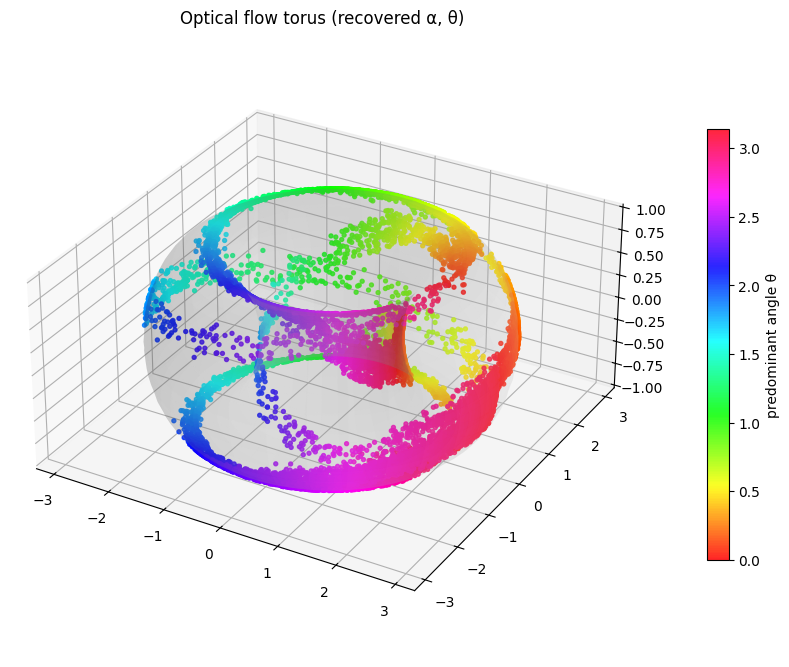

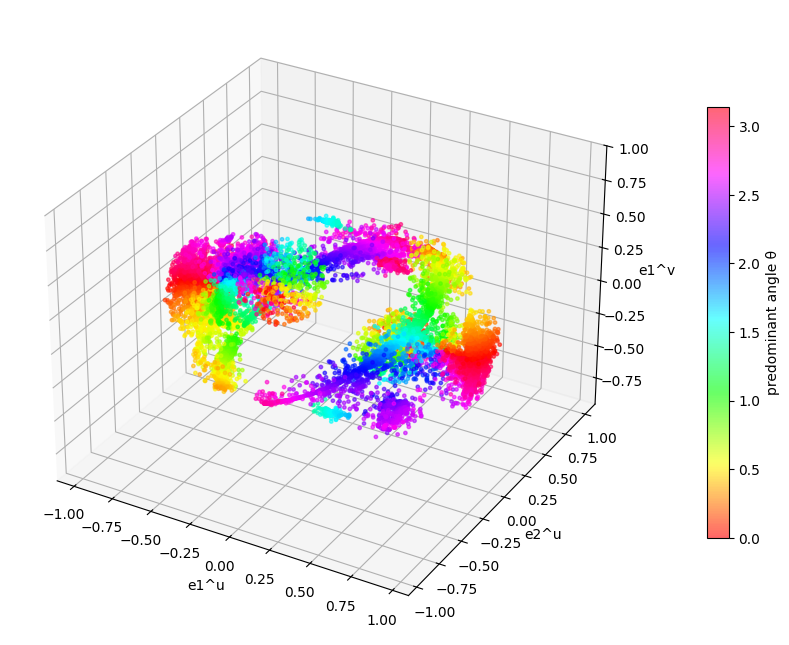

[array([ 0.81694464,  0.8234205 ,  0.82405755, ..., -0.020474  ,
        -0.16813332, -0.03501438]),
 array([ 0.04425281,  0.04168306,  0.01496401, ..., -0.00530017,
        -0.68667525, -0.51711936]),
 array([-0.09653851, -0.09735451, -0.08286794, ...,  0.68460156,
         0.70325982,  0.84554741])]

In [13]:
import numpy as np
import matplotlib.pyplot as plt   # 3D works via projection="3d", no extra import needed


def predominant_angle(data):
    X = (data.detach().cpu().numpy() if hasattr(data, "detach") else np.asarray(data, float))[:, :18]
    u = X[:, :9]  - X[:, :9].mean(1, keepdims=True)
    v = X[:, 9:18] - X[:, 9:18].mean(1, keepdims=True)
    a, c, b = (u*u).sum(1), (v*v).sum(1), (u*v).sum(1)
    return 0.5 * np.arctan2(2*b, a - c) % np.pi   # in [0, pi)

def grid_laplacian():
    idx = lambda r, c: r + 3 * c                 # column-major, matches reshape(order='F')
    L = np.zeros((9, 9))
    for r in range(3):
        for c in range(3):
            i = idx(r, c)
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                rr, cc = r + dr, c + dc
                if 0 <= rr < 3 and 0 <= cc < 3:
                    L[i, i] += 1
                    L[i, idx(rr, cc)] -= 1
    return L

def dct_flow_basis():
    L = grid_laplacian()
    n = np.arange(3)
    phi = np.stack([np.cos(np.pi * (n + 0.5) * k / 3) for k in range(3)])  # 1D DCT-II
    order = [(0,1),(1,0),(1,1),(0,2),(2,0),(1,2),(2,1),(2,2)]  # e1..e8; e1=horiz, e2=vert grad
    E = []
    for k, l in order:
        M = np.outer(phi[k], phi[l])            # M[row, col]
        v = M.flatten(order="F")                # same column-major layout as the data
        v = v - v.mean()                        # mean zero
        v = v / np.sqrt(v @ L @ v)              # contrast norm one
        E.append(v)
    E = np.array(E)                             # (8, 9)
    Z = np.zeros((8, 9))
    eu = np.hstack([E, Z])                      # (8,18)  e_i^u
    ev = np.hstack([Z, E])                      # (8,18)  e_i^v
    Dflow = np.block([[L, Z.T @ Z * 0], [np.zeros((9,9)), L]])  # blockdiag(L, L)
    Dflow = np.zeros((18, 18)); Dflow[:9, :9] = L; Dflow[9:, 9:] = L
    return eu, ev, Dflow

def recover_torus_coords(data):
    """theta = predominant angle (base circle, [0,pi)); alpha = fiber-circle angle ([0,2pi))."""
    X = (data.detach().cpu().numpy() if hasattr(data, "detach") else np.asarray(data, float))[:, :18]
    eu, ev, D = dct_flow_basis()
    theta = predominant_angle(data)
    e1u, e2u, e1v, e2v = eu[0], eu[1], ev[0], ev[1]
    ct, st = np.cos(theta)[:, None], np.sin(theta)[:, None]
    bx = ct * e1u + st * e1v          # per-patch fiber axes (the Figure-8 basis)
    by = ct * e2u + st * e2v
    Xd = X @ D                        # contrast metric, applied once
    px = np.einsum("ij,ij->i", Xd, bx)
    py = np.einsum("ij,ij->i", Xd, by)
    alpha = np.arctan2(py, px) % (2 * np.pi)
    return alpha, theta

def plot_torus_3d(data, R=2.0, r=0.9, wrap=2, show_surface=True, s=8):
    """Place each patch on the donut. wrap=2 maps theta in [0,pi) once around the major circle
    (predominant direction is a line, RP^1, so it double-covers to the full circle)."""
    alpha, theta = recover_torus_coords(data)
    phi = wrap * theta
    Xc = (R + r * np.cos(alpha)) * np.cos(phi)
    Yc = (R + r * np.cos(alpha)) * np.sin(phi)
    Zc = r * np.sin(alpha)

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")
    if show_surface:
        a = np.linspace(0, 2*np.pi, 60); t = np.linspace(0, 2*np.pi, 60)
        a, t = np.meshgrid(a, t)
        ax.plot_surface((R + r*np.cos(a))*np.cos(t), (R + r*np.cos(a))*np.sin(t), r*np.sin(a),
                        color="lightgray", alpha=0.15, linewidth=0)
    p = ax.scatter(Xc, Yc, Zc, c=theta, cmap="hsv", vmin=0, vmax=np.pi, s=s, alpha=0.85)
    fig.colorbar(p, ax=ax, label="predominant angle θ", fraction=.03, pad=.1)
    ax.set_title("Optical flow torus (recovered α, θ)")
    ax.set_box_aspect((1, 1, 0.5))
    plt.tight_layout(); plt.show()
    return alpha, theta

def plot_dct_projection_3d(data, axes_spec=(("u", 1), ("u", 2), ("v", 1)),
                           color_by_angle=True, s=6):
    """Literal 3D scatter onto three DCT-flow axes, e.g. e1^u, e2^u, e1^v."""
    X = (data.detach().cpu().numpy() if hasattr(data, "detach") else np.asarray(data, float))[:, :18]
    eu, ev, D = dct_flow_basis()
    pick = {"u": eu, "v": ev}
    coords = [X @ (D @ pick[c][k-1]) for c, k in axes_spec]   # contrast-norm projections

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")
    kw = dict(c=predominant_angle(data), cmap="hsv", vmin=0, vmax=np.pi) if color_by_angle else dict(c="k")
    p = ax.scatter(*coords, s=s, alpha=0.6, **kw)
    ax.set_xlabel(f"e{axes_spec[0][1]}^{axes_spec[0][0]}")
    ax.set_ylabel(f"e{axes_spec[1][1]}^{axes_spec[1][0]}")
    ax.set_zlabel(f"e{axes_spec[2][1]}^{axes_spec[2][0]}")
    if color_by_angle:
        fig.colorbar(p, ax=ax, label="predominant angle θ", fraction=.03, pad=.1)
    plt.tight_layout(); plt.show()
    return coords


# usage
plot_torus_3d(result)                                        # the donut
plot_dct_projection_3d(result, axes_spec=(("u",1),("u",2),("v",1)))   # literal 3-axis scatter